# Calculating the DFS

Calculating the DFS based on the setting from the Widar3.0 paper and saved in 'DFS' folder.

In [5]:
import numpy as np
import itertools
from typing import Tuple
from scipy.signal import butter, filtfilt
from scipy import signal
import torch


def get_CSI(csi_data: 'CSIData', squeeze_output: bool = False) -> Tuple[np.array, int, int]:
    frames = csi_data.frames
    try:
        csi_shape = frames[0].csi_matrix.shape
    except:
        return (None,0,0)

    no_frames = len(frames)
    no_subcarriers = csi_shape[0]

    # Matrices should be Frames * Subcarriers * Rx * Tx.
    # Single Rx/Tx streams should be squeezed.
    if len(csi_shape) == 3:
        # Intel data comes as Subcarriers * Rx * Tx.
        no_rx_antennas = csi_shape[1]
        no_tx_antennas = csi_shape[2]
    elif len(csi_shape) == 2 or len(csi_shape) == 1:
        # Single antenna stream.
        no_rx_antennas = 1
        no_tx_antennas = 1
    else:
        # Error. Unknown CSI shape.
        print("Error: Unknown CSI shape.")

    csi = np.zeros((no_frames, no_subcarriers, no_rx_antennas, no_tx_antennas), dtype=complex)
    ranges = itertools.product(*[range(n) for n in [no_frames, no_subcarriers, no_rx_antennas, no_tx_antennas]])
    is_single_antenna = no_rx_antennas == 1 and no_tx_antennas == 1

    drop_indices = []
    for frame, subcarrier, rx_antenna_index, tx_antenna_index in ranges:
        frame_data = frames[frame].csi_matrix
        if subcarrier >= frame_data.shape[0]:
            # Inhomogenous component
            # Skip frame for now. Need a better method soon.
            continue

        subcarrier_data = frame_data[subcarrier]
        if subcarrier_data.shape != (no_rx_antennas, no_tx_antennas) and not is_single_antenna:
            if rx_antenna_index >= subcarrier_data.shape[0] or tx_antenna_index >= subcarrier_data.shape[1]:
                # Inhomogenous component
                # Skip frame for now. Need a better method soon.
                drop_indices.append(frame)
                continue
        csi[frame][subcarrier][rx_antenna_index][tx_antenna_index] = subcarrier_data if is_single_antenna else \
            subcarrier_data[rx_antenna_index][tx_antenna_index]  
    csi = np.delete(csi, drop_indices, 0)
    csi_data.timestamps = [x for i, x in enumerate(csi_data.timestamps) if i not in drop_indices]
    if squeeze_output:
        csi = np.squeeze(csi)
    return (csi, no_frames, no_subcarriers)

def nextpow2(i):
    return np.ceil(np.log2(i))

def autocorr(x):
    nFFT = int(2**(nextpow2(len(x))+1))
    F = np.fft.fft(x,nFFT)
    F = F*np.conj(F)
    acf = np.fft.ifft(F)
    acf = acf[0:len(x)] # Retain nonnegative lags
    acf = np.real(acf)
    acf = acf/acf[0] # Normalize
    return acf

def preprocess_CSI(csi_matrix: np.array, csi_sample_rate: int = 1000):
    '''ArithmeticError
    Preprocesses the CSI matrix by applying phase cleaning (Widar3.0) and a lowpass and highpass filter.
    Then, calculates the motion statistics.
    The shape of the CSI matrix (complex-valued) should be Frames (time dimension) * Subcarriers * Rx * Tx.
    Returns the processed CSI matrix and the motion statistics.
    '''
    # define the lowpass and highpass filter
    half_rate = csi_sample_rate / 2
    uppe_orde = 6
    uppe_stop = 60
    if uppe_stop > half_rate:
        uppe_stop = half_rate - 1
    lowe_orde = 3
    lowe_stop = 2
    lu, ld = butter(uppe_orde, uppe_stop / half_rate, 'low')  
    hu, hd = butter(lowe_orde, lowe_stop / half_rate, 'high')
    num_frames, num_subcarriers, num_rx, num_tx = csi_matrix.shape

    # phase cleaning
    if num_rx == 1:
        cleaned_csi = csi_matrix
    elif num_rx == 2:
        cleaned_csi = np.zeros((num_frames, num_subcarriers, 1, num_tx), dtype=complex)
        cleaned_csi = csi_matrix[:, :, 0, :] * np.conj(csi_matrix[:, :, 1, :])
    else:
        cleaned_csi = np.zeros((num_frames, num_subcarriers, num_rx, num_tx), dtype=complex)
        for i in range(num_rx):
            cleaned_csi[:, :, i, :] = csi_matrix[:, :, i, :] * np.conj(csi_matrix[:, :, (i + 1)%num_rx, :])

     # apply the lowpass filter
    for i in range(num_subcarriers):
        for j in range(num_rx):
            for k in range(num_tx):
                cleaned_csi[:, i, j, k] = filtfilt(lu, ld, cleaned_csi[:, i, j, k])
    # apply the highpass filter
    for i in range(num_subcarriers):
        for j in range(num_rx):
            for k in range(num_tx):
                cleaned_csi[:, i, j, k] = filtfilt(lu, ld, cleaned_csi[:, i, j, k])

    return cleaned_csi

def get_csi_dfs(csi_data, samp_rate = 1000, window_size = 256, window_step = 10):
    '''
    input csi_data: [Time_dim, num_subcarriers, Rx*Tx,] (complex numpy array)
    return dfs spetrum with shape: [Time_bins, freq_bins, num_subcarriers, Rx*Tx, 2]
    '''
    
    half_rate = samp_rate / 2
    uppe_stop = 60
    freq_bins_unwrap = np.concatenate((np.arange(0, half_rate, 1) / samp_rate, np.arange(-half_rate, 0, 1) / samp_rate))
    freq_lpf_sele = np.logical_and(np.less_equal(freq_bins_unwrap,(uppe_stop / samp_rate)),np.greater_equal(freq_bins_unwrap,(-uppe_stop / samp_rate)))
    freq_lpf_positive_max = 60
    
    # DC removal
    csi_data = csi_data.numpy()
    csi_data = csi_data - np.mean(csi_data, axis=0)
    noverlap = window_size - window_step
    
    freq, ticks, freq_time_prof_allfreq = signal.stft(csi_data, 
                                                      fs=samp_rate, 
                                                      nfft=samp_rate,
                                                        window=('gaussian', 
                                                                window_size), 
                                                        nperseg=window_size, 
                                                        noverlap=noverlap, 
                                                        return_onesided=False,
                                                        padded=True, 
                                                        axis=0)
    
    freq_time_prof_allfreq = np.array(freq_time_prof_allfreq)
    freq_time_prof = freq_time_prof_allfreq[freq_lpf_sele, :]  # shape: [freq_bins, num_subcarriers, Rx*Tx, Time_bins]
    freq_time_prof = np.roll(freq_time_prof, freq_lpf_positive_max, axis=0) # shape: [freq_bins, num_subcarriers, Rx*Tx, Time_bins]
    freq_bin = np.array(freq)[freq_lpf_sele]
    freq_bin = np.roll(freq_bin, freq_lpf_positive_max, axis=0)
    # change freq_time_prof shape to: [Time_bins, freq_bins, num_subcarriers, Rx*Tx]
    freq_time_prof = np.transpose(freq_time_prof, (3, 0, 1, 2))
    freq_time_prof_real = freq_time_prof.real
    freq_time_prof_imag = freq_time_prof.imag
    # we get a tensor with shape: [Time_bins, freq_bins, num_subcarriers, Rx*Tx, 2]
    freq_time_prof = np.stack([freq_time_prof_real, freq_time_prof_imag], axis=-1)
    return freq_bin, ticks, torch.tensor(freq_time_prof)


In [6]:
import os

CSI_folders = os.listdir('CSI')
print(CSI_folders)

['20181205', '20181115', '20181127', '20181118', '20181112', '20181211', '20181208', '20181116', '20181130', '20181209', '20181121', '20181204', '20181109', '20181128', '20181117']


In [7]:
folder_index = 0

subfolders = os.listdir('CSI/' + CSI_folders[folder_index])
print(subfolders)

['user3', 'user2']


In [8]:
subfolder_index = 0

files = os.listdir('CSI/' + CSI_folders[folder_index] + '/' + subfolders[subfolder_index])
print(files)
print(len(files))

['user3-2-2-1-2-r2.dat', 'user3-4-3-2-4-r3.dat', 'user3-6-3-5-2-r5.dat', 'user3-1-2-2-2-r6.dat', 'user3-6-1-4-1-r6.dat', 'user3-4-5-1-1-r6.dat', 'user3-5-2-3-3-r3.dat', 'user3-1-1-4-3-r1.dat', 'user3-1-4-3-4-r5.dat', 'user3-3-4-4-2-r3.dat', 'user3-6-5-4-4-r6.dat', 'user3-6-4-1-5-r4.dat', 'user3-2-5-5-5-r3.dat', 'user3-4-1-1-4-r6.dat', 'user3-3-5-1-3-r1.dat', 'user3-2-2-3-1-r4.dat', 'user3-5-1-5-2-r4.dat', 'user3-3-5-5-2-r6.dat', 'user3-5-1-1-3-r3.dat', 'user3-6-4-5-4-r3.dat', 'user3-4-4-2-2-r5.dat', 'user3-2-5-1-4-r4.dat', 'user3-4-1-5-5-r1.dat', 'user3-2-1-3-2-r2.dat', 'user3-5-2-5-1-r2.dat', 'user3-2-4-4-5-r6.dat', 'user3-1-3-1-1-r5.dat', 'user3-2-3-2-1-r1.dat', 'user3-5-5-3-5-r5.dat', 'user3-4-2-3-4-r6.dat', 'user3-2-1-1-1-r4.dat', 'user3-3-3-4-4-r5.dat', 'user3-1-3-3-2-r3.dat', 'user3-5-3-2-3-r6.dat', 'user3-2-2-5-3-r5.dat', 'user3-6-3-1-3-r2.dat', 'user3-5-3-3-4-r2.dat', 'user3-2-2-4-4-r1.dat', 'user3-6-2-5-5-r4.dat', 'user3-4-2-2-3-r2.dat', 'user3-2-3-1-5-r3.dat', 'user3-3-3-5-3-

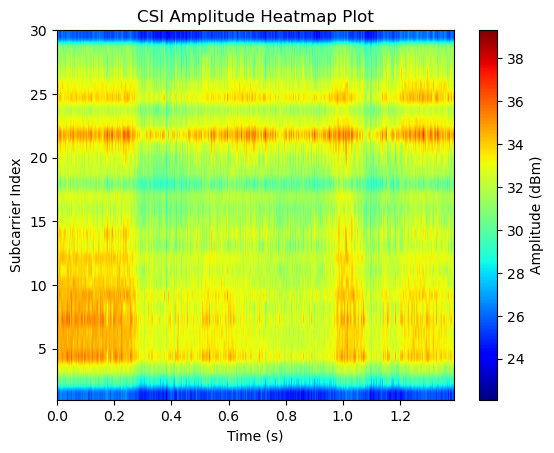

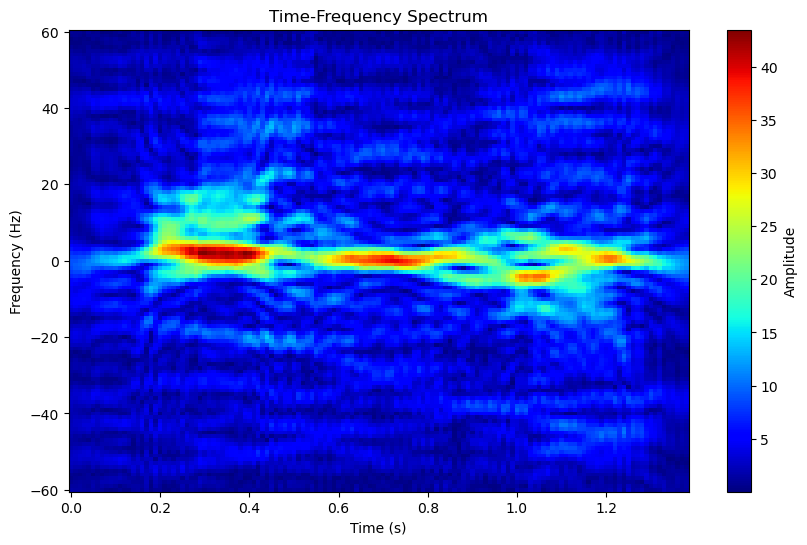

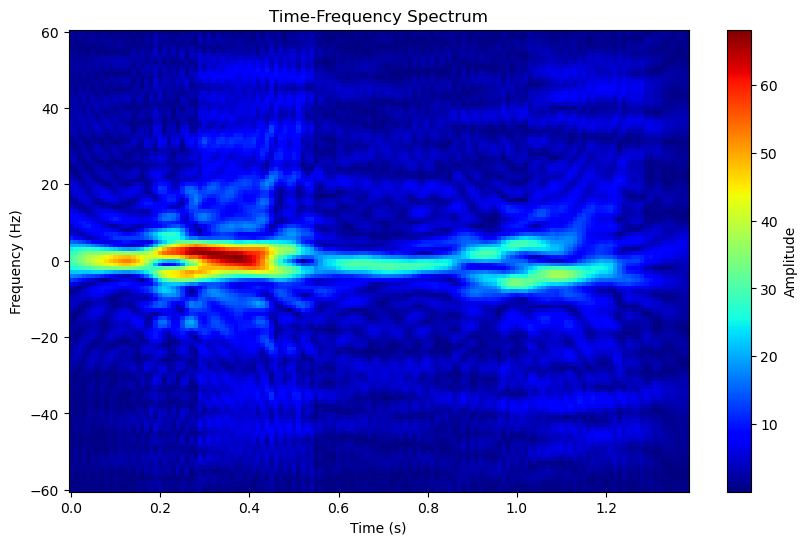

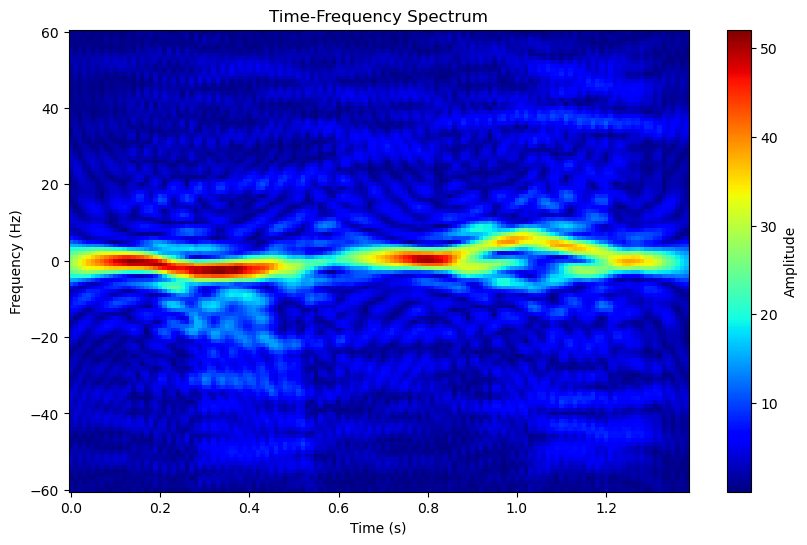

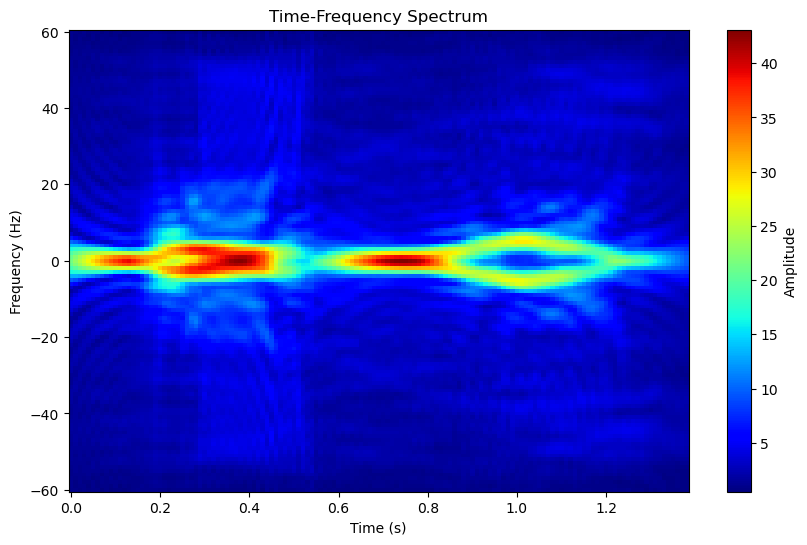

In [16]:
from CSIKit.reader import IWLBeamformReader
from CSIKit.tools.batch_graph import BatchGraph
import matplotlib.pyplot as plt

# file_name = 'CSI/' + CSI_folders[folder_index] + '/' + subfolders[subfolder_index] + '/' + files[1000]
file_name = 'CSI/20181116/user1/user1-1-6-1-1-r2.dat'
file_name = 'CSI/20181121/user1/user1-1-1-1-1-r1.dat'

my_reader = IWLBeamformReader()
csi_data = my_reader.read_file(file_name) 
csi_matrix, _, _ = get_CSI(csi_data)  # shape: (frames, subcarriers, Rx, Tx)

BatchGraph.plot_heatmap(np.abs(csi_matrix[:,:, 0,0]), csi_data.timestamps)

csi_matrix = preprocess_CSI(csi_matrix)
csi = torch.tensor(csi_matrix)  # shape: (frames, subcarriers, Rx, Tx)
csi = csi.view(csi.shape[0], csi.shape[1], csi.shape[2]*csi.shape[3])  # shape: (frames, subcarriers, Rx*Tx)
freq_bin, ticks, freq_time_prof = get_csi_dfs(csi, samp_rate = 1000, window_size = 256, window_step = 10) 


freq_time_prof = freq_time_prof.numpy()
magnitude = np.sqrt(freq_time_prof[..., 0]**2 + freq_time_prof[..., 1]**2)  # Calculate magnitude from real and imaginary parts


plt.figure(figsize=(10, 6))
plt.pcolormesh(ticks, freq_bin, magnitude[:,:,2,0].T, shading='auto', cmap='jet')
plt.colorbar(label='Amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Time-Frequency Spectrum')
plt.show()

plt.figure(figsize=(10, 6))
plt.pcolormesh(ticks, freq_bin, magnitude[:,:,2,1].T, shading='auto', cmap='jet')
plt.colorbar(label='Amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Time-Frequency Spectrum')
plt.show()

# Visualize the time-frequency spectrum
plt.figure(figsize=(10, 6))
plt.pcolormesh(ticks, freq_bin, magnitude[:,:,2,2].T, shading='auto', cmap='jet')
plt.colorbar(label='Amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Time-Frequency Spectrum')
plt.show()

averaged_spectrum = np.mean(magnitude, axis=(2, 3))  # Average along subcarriers and Rx*Tx

# Visualize the time-frequency spectrum
plt.figure(figsize=(10, 6))
plt.pcolormesh(ticks, freq_bin, averaged_spectrum.T, shading='auto', cmap='jet')
plt.colorbar(label='Amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Time-Frequency Spectrum')
plt.show()

# Check the stored DFS

(114, 121, 30, 3, 2)
float64
(114, 121, 30, 3)


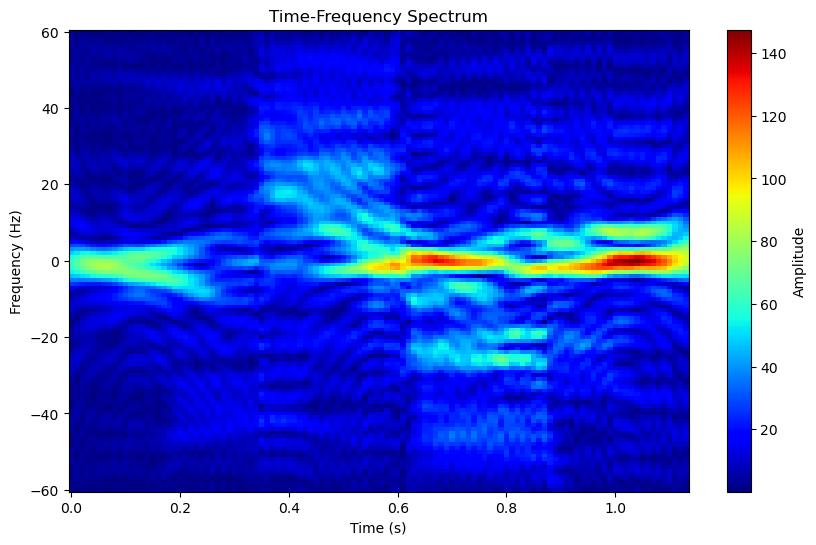

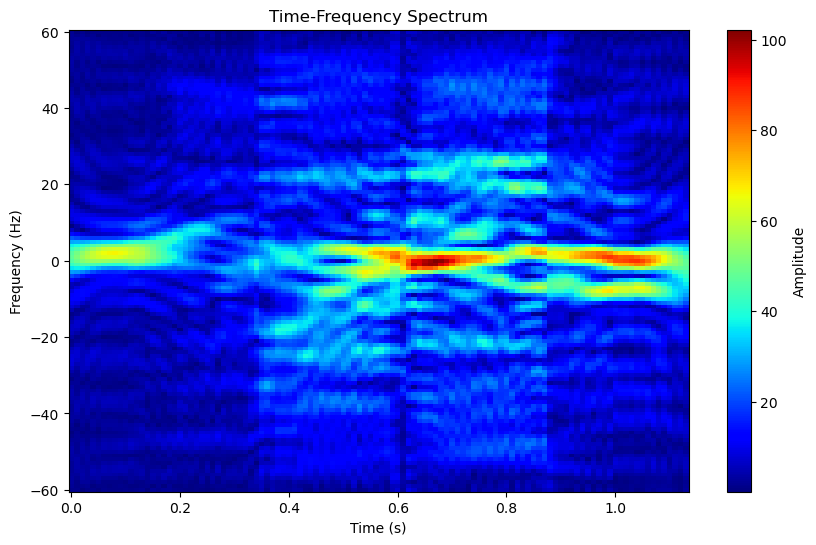

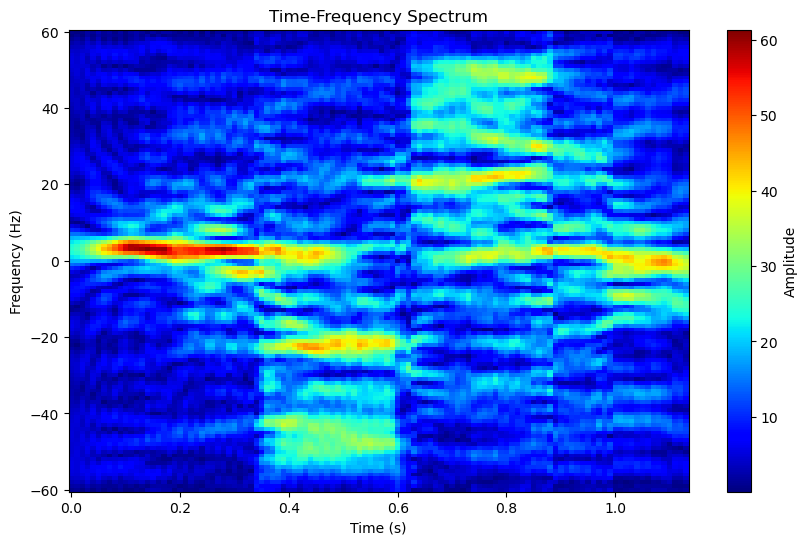

In [1]:
from CSIKit.reader import IWLBeamformReader
from CSIKit.tools.batch_graph import BatchGraph
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

csi_matrix = np.load('DFS/20181121/user1/user1-1-1-2-10-r2.npy')
print(csi_matrix.shape)  # shape: (frames (Time bins), freq_bins, subcarriers, Rx*Tx, 2)
print(csi_matrix.dtype)

magnitude = np.sqrt(csi_matrix[..., 0]**2 + csi_matrix[..., 1]**2)  # Calculate magnitude from real and imaginary parts
print(magnitude.shape)
ticks = np.arange(0.0, csi_matrix.shape[0] / 100, 0.01)
freq_bin = np.arange(-60, 61, 1)

plt.figure(figsize=(10, 6))
plt.pcolormesh(ticks, freq_bin, magnitude[:,:,2,0].T, shading='auto', cmap='jet')
plt.colorbar(label='Amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Time-Frequency Spectrum')
plt.show()

plt.figure(figsize=(10, 6))
plt.pcolormesh(ticks, freq_bin, magnitude[:,:,2,1].T, shading='auto', cmap='jet')
plt.colorbar(label='Amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Time-Frequency Spectrum')
plt.show()

# Visualize the time-frequency spectrum
plt.figure(figsize=(10, 6))
plt.pcolormesh(ticks, freq_bin, magnitude[:,:,2,2].T, shading='auto', cmap='jet')
plt.colorbar(label='Amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Time-Frequency Spectrum')
plt.show()

(114, 121, 30, 3, 2)
float32
(114, 121, 30, 3)


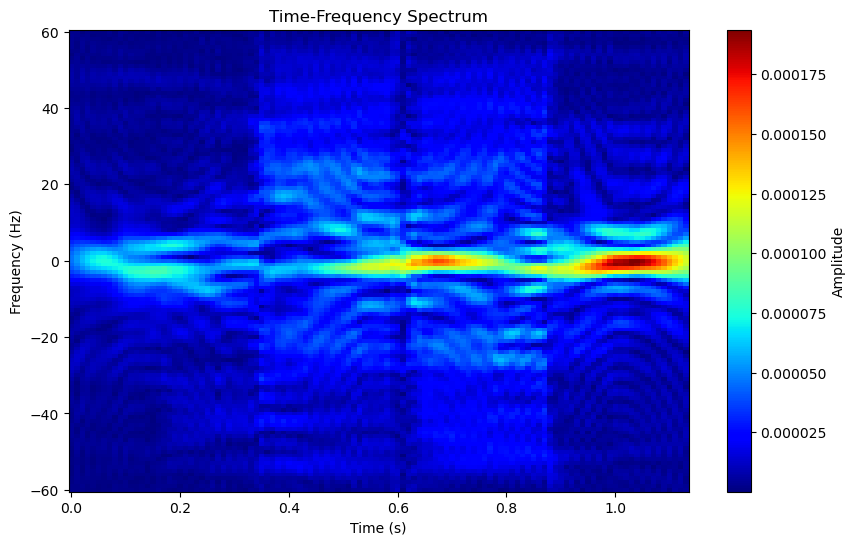

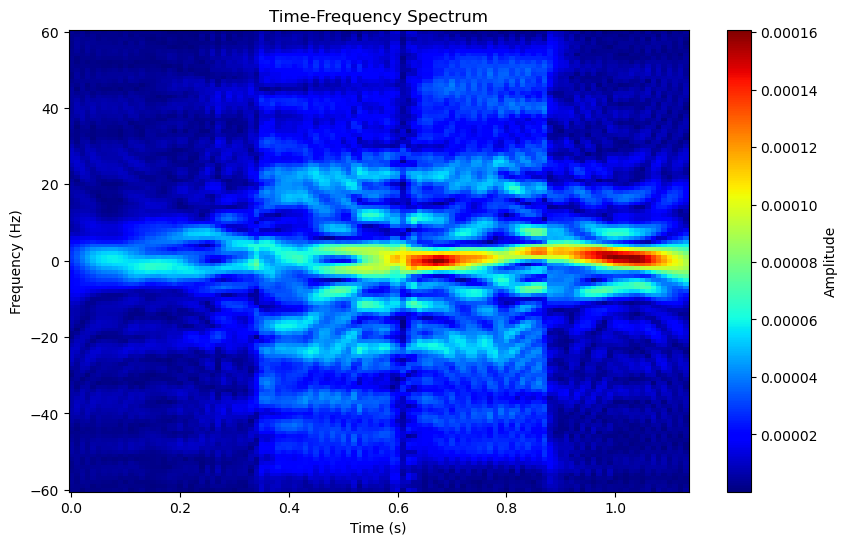

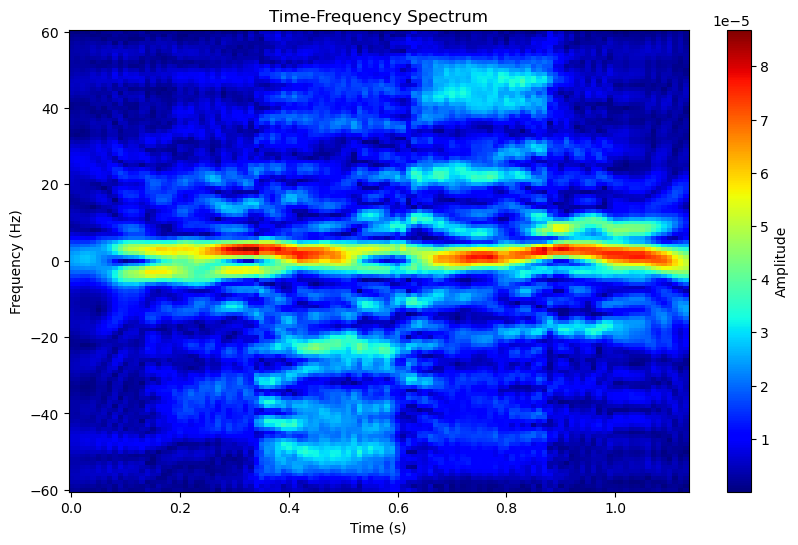

In [1]:
from CSIKit.reader import IWLBeamformReader
from CSIKit.tools.batch_graph import BatchGraph
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

csi_matrix = np.load('DFS/20181121/user1/user1-1-1-2-10-r2.npy')
print(csi_matrix.shape)  # shape: (frames (Time bins), freq_bins, subcarriers, Rx*Tx, 2)
print(csi_matrix.dtype)

magnitude = np.sqrt(csi_matrix[..., 0]**2 + csi_matrix[..., 1]**2)  # Calculate magnitude from real and imaginary parts
print(magnitude.shape)
ticks = np.arange(0.0, csi_matrix.shape[0] / 100, 0.01)
freq_bin = np.arange(-60, 61, 1)

plt.figure(figsize=(10, 6))
plt.pcolormesh(ticks, freq_bin, magnitude[:,:,2,0].T, shading='auto', cmap='jet')
plt.colorbar(label='Amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Time-Frequency Spectrum')
plt.show()

plt.figure(figsize=(10, 6))
plt.pcolormesh(ticks, freq_bin, magnitude[:,:,2,1].T, shading='auto', cmap='jet')
plt.colorbar(label='Amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Time-Frequency Spectrum')
plt.show()

# Visualize the time-frequency spectrum
plt.figure(figsize=(10, 6))
plt.pcolormesh(ticks, freq_bin, magnitude[:,:,2,2].T, shading='auto', cmap='jet')
plt.colorbar(label='Amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Time-Frequency Spectrum')
plt.show()

(209, 121, 30, 3, 2)
float64
(209, 121, 30, 3)


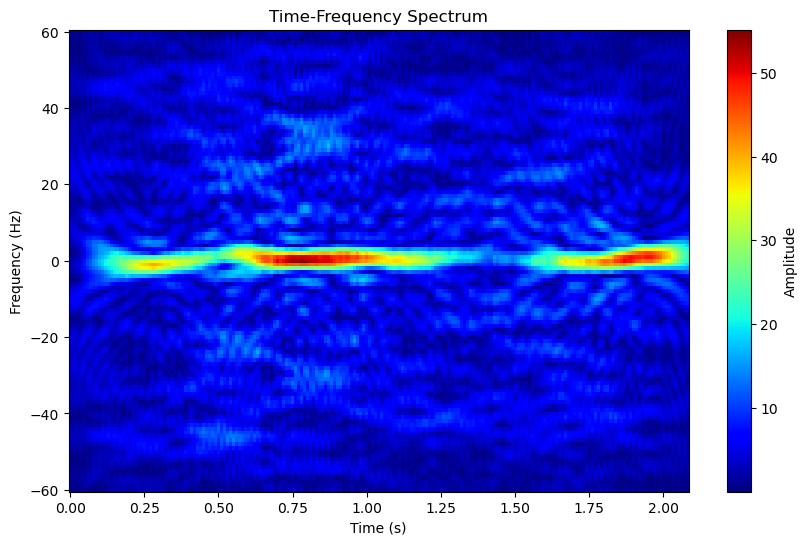

In [4]:
csi_matrix = np.load('DFS_dense/20181205/user3/user3-6-2-4-4-r3.npy')
print(csi_matrix.shape)  # shape: (frames (Time bins), freq_bins, subcarriers, Rx*Tx, 2)
print(csi_matrix.dtype)

magnitude = np.sqrt(csi_matrix[..., 0]**2 + csi_matrix[..., 1]**2)  # Calculate magnitude from real and imaginary parts
print(magnitude.shape)
ticks = np.arange(0.0, csi_matrix.shape[0] / 100, 0.01)
freq_bin = np.arange(-60, 61, 1)

plt.figure(figsize=(10, 6))
plt.pcolormesh(ticks, freq_bin, magnitude[:,:,2,0].T, shading='auto', cmap='jet')
plt.colorbar(label='Amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Time-Frequency Spectrum')
plt.show()

In [2]:
csi_matrix = np.load('DFS_dense/20181205/user3/user3-6-2-4-4-r3.npy')
print(csi_matrix.shape)  # shape: (frames (Time bins), freq_bins, subcarriers, Rx*Tx, 2)
print(csi_matrix.dtype)

magnitude = np.sqrt(csi_matrix[..., 0]**2 + csi_matrix[..., 1]**2)  # Calculate magnitude from real and imaginary parts
print(magnitude.shape)
ticks = np.arange(0.0, csi_matrix.shape[0] / 100, 0.01)
freq_bin = np.arange(-60, 61, 1)

plt.figure(figsize=(10, 6))
plt.pcolormesh(ticks, freq_bin, magnitude[:,:,2,0].T, shading='auto', cmap='jet')
plt.colorbar(label='Amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Time-Frequency Spectrum')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'DFS_dense/20181205/user3/user3-6-2-4-4-r3.npy'

(209, 121, 30, 3, 2)
float16
(209, 121, 30, 3)


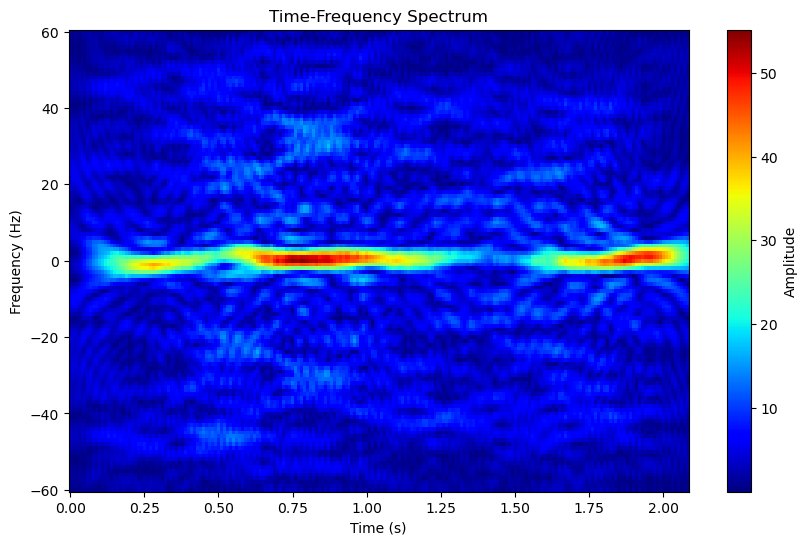

In [5]:
csi_matrix = np.load('DFS/20181205/user3/user3-6-2-4-4-r3.npy')
print(csi_matrix.shape)  # shape: (frames (Time bins), freq_bins, subcarriers, Rx*Tx, 2)
# convert to float16
print(csi_matrix.dtype)

magnitude = np.sqrt(csi_matrix[..., 0]**2 + csi_matrix[..., 1]**2)  # Calculate magnitude from real and imaginary parts
print(magnitude.shape)
ticks = np.arange(0.0, csi_matrix.shape[0] / 100, 0.01)
freq_bin = np.arange(-60, 61, 1)

plt.figure(figsize=(10, 6))
plt.pcolormesh(ticks, freq_bin, magnitude[:,:,2,0].T, shading='auto', cmap='jet')
plt.colorbar(label='Amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Time-Frequency Spectrum')
plt.show()

(209, 121, 30, 3, 2)
float32
(209, 121, 30, 3)


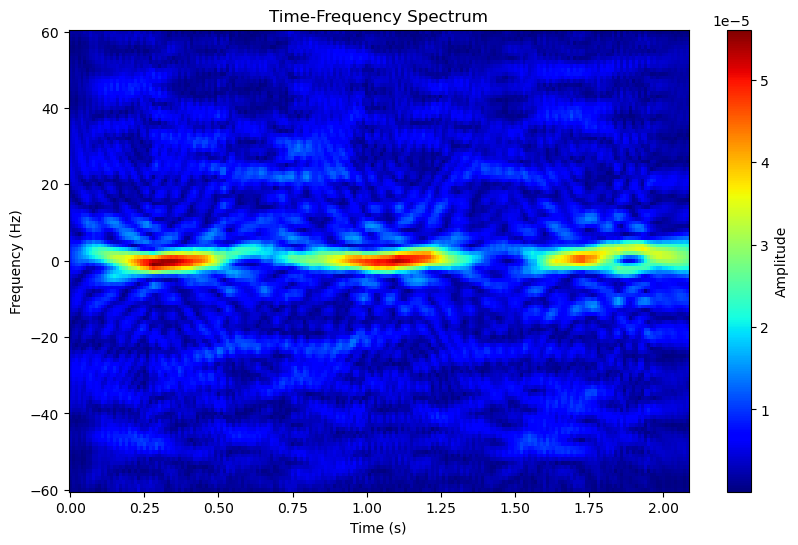

In [3]:
csi_matrix = np.load('DFS/20181205/user3/user3-6-2-4-4-r3.npy')
print(csi_matrix.shape)  # shape: (frames (Time bins), freq_bins, subcarriers, Rx*Tx, 2)
# convert to float16
print(csi_matrix.dtype)

magnitude = np.sqrt(csi_matrix[..., 0]**2 + csi_matrix[..., 1]**2)  # Calculate magnitude from real and imaginary parts
print(magnitude.shape)
ticks = np.arange(0.0, csi_matrix.shape[0] / 100, 0.01)
freq_bin = np.arange(-60, 61, 1)

plt.figure(figsize=(10, 6))
plt.pcolormesh(ticks, freq_bin, magnitude[:,:,2,0].T, shading='auto', cmap='jet')
plt.colorbar(label='Amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Time-Frequency Spectrum')
plt.show()